# Satellite Image Semantic Segmentation with UNet

**Author:** Soojal  
**Task:** Multi-class semantic segmentation of satellite imagery  
**Architecture:** UNet (implemented from scratch in TensorFlow/Keras)  
**Dataset:** Semantic Segmentation Dataset — 8 tiles, 6 land-cover classes  
**Loss:** Focal Loss + Dice Loss (combined)  
**Metric:** Jaccard coefficient (IoU)

---

## Pipeline Overview

1. **Data Ingestion** — Load and patch satellite images and RGB masks from 8 map tiles  
2. **Preprocessing** — MinMax normalisation, RGB-to-label mask conversion  
3. **Dataset Preparation** — Train/test split with one-hot encoded labels  
4. **Model** — UNet with encoder depth [16→32→64→128→256] and skip connections  
5. **Loss & Metrics** — Combined Focal + Dice loss with per-class weights; Jaccard IoU  
6. **Training** — Adam optimiser, 5 epochs, WandB experiment tracking  
7. **Evaluation** — Qualitative visualisation + activation map inspection (keract)  

> **Dataset:** [Semantic Segmentation Dataset](https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery) — Dubai aerial imagery, 72 images across 8 tiles.


## Section 1 — Environment Setup

In [1]:
!pip install -q patchify segmentation-models keract wandb
!pip install -q tensorflow opencv-python-headless pillow scikit-learn

## Section 2 — Imports

In [2]:
import os
import random
import numpy as np
import cv2
from PIL import Image
from patchify import patchify
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import backend as k
from keras.models import Model
from keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose,
                          Dropout, concatenate)
from keras.utils import to_categorical
import segmentation_models as sm
import wandb
from wandb.keras import WandbCallback

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs available: {len(tf.config.list_physical_devices("GPU"))}')

TensorFlow: 2.13.0
GPUs available: 1


## Section 3 — Configuration

Update `DATASET_ROOT` to point to your local dataset directory or Google Drive mount.

> 💡 WandB API key: store in an environment variable or Colab Secret — never hardcode it.


In [3]:
# ── Paths (update to match your environment) ────────────────
DATASET_ROOT   = '/content/drive/MyDrive/Semantic segmentation dataset'
DATASET_NAME   = 'Semantic segmentation dataset'
MODEL_SAVE_PATH = 'satellite_segmentation.h5'

# ── Hyperparameters ──────────────────────────────────────────
PATCH_SIZE   = 256   # pixels per patch (height and width)
N_CLASSES    = 6     # water, land, road, building, vegetation, unlabeled
BATCH_SIZE   = 16
EPOCHS       = 5
TEST_SIZE    = 0.2
RANDOM_SEED  = 42

# ── WandB (uses env var; set via: export WANDB_API_KEY=your_key) ─
WANDB_PROJECT = 'satellite-segmentation'

print('Config loaded.')

Config loaded.


## Section 4 — Class Definitions

Each pixel in the RGB mask corresponds to one of 6 land-cover classes.  
Class colours follow the dataset annotation standard.

| Class | Colour (hex) | Label ID |
|---|---|---|
| Building | `#3C1098` | 3 |
| Land | `#8429F6` | 1 |
| Road | `#6EC1E4` | 2 |
| Vegetation | `#FEDD3A` | 4 |
| Water | `#E2A929` | 0 |
| Unlabeled | `#9B9B9B` | 5 |


In [4]:
def hex_to_rgb(hex_str):
    hex_str = hex_str.lstrip('#')
    return np.array(tuple(int(hex_str[i:i+2], 16) for i in (0, 2, 4)))

CLASS_COLOURS = {
    'water':      (hex_to_rgb('#E2A929'), 0),
    'land':       (hex_to_rgb('#8429F6'), 1),
    'road':       (hex_to_rgb('#6EC1E4'), 2),
    'building':   (hex_to_rgb('#3C1098'), 3),
    'vegetation': (hex_to_rgb('#FEDD3A'), 4),
    'unlabeled':  (hex_to_rgb('#9B9B9B'), 5),
}

print('Class colour mappings:')
for name, (colour, label_id) in CLASS_COLOURS.items():
    print(f'  [{label_id}] {name:12s} → RGB{tuple(colour)}')

Class colour mappings:
  [0] water        → RGB(226, 169, 41)
  [1] land         → RGB(132, 41, 246)
  [2] road         → RGB(110, 193, 228)
  [3] building     → RGB(60, 16, 152)
  [4] vegetation   → RGB(254, 221, 58)
  [5] unlabeled    → RGB(155, 155, 155)


## Section 5 — Data Ingestion & Patching

Satellite tiles are large images. We crop each to the nearest multiple of `PATCH_SIZE`  
and extract non-overlapping 256×256 patches for training.

**Dataset structure:**
```
Semantic segmentation dataset/
├── Tile 1/
│   ├── images/  (image_part_001.jpg ... image_part_009.jpg)
│   └── masks/   (image_part_001.png ... image_part_009.png)
├── Tile 2/ ...
└── Tile 8/
```


In [5]:
minmaxscaler = MinMaxScaler()

def load_and_patch_dataset(dataset_root, dataset_name, patch_size):
    """
    Load satellite images and masks from all tiles.
    Crops each image to the nearest patch_size multiple and extracts patches.

    Returns:
        image_dataset: list of normalised image patches (H, W, 3)
        mask_dataset:  list of RGB mask patches (H, W, 3)
    """
    image_dataset, mask_dataset = [], []

    for tile_id in range(1, 9):
        for image_id in range(1, 20):
            for image_type, ext in [('images', 'jpg'), ('masks', 'png')]:
                path = (f'{dataset_root}/{dataset_name}/Tile {tile_id}/'
                        f'{image_type}/image_part_00{image_id}.{ext}')
                img = cv2.imread(path, 1)
                if img is None:
                    continue
                if image_type == 'masks':
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Crop to nearest patch_size multiple
                size_x = (img.shape[1] // patch_size) * patch_size
                size_y = (img.shape[0] // patch_size) * patch_size
                img = np.array(Image.fromarray(img).crop((0, 0, size_x, size_y)))

                patches = patchify(img, (patch_size, patch_size, 3), step=patch_size)
                for i in range(patches.shape[0]):
                    for j in range(patches.shape[1]):
                        patch = patches[i, j, 0]
                        if image_type == 'images':
                            patch = minmaxscaler.fit_transform(
                                patch.reshape(-1, 3)).reshape(patch.shape)
                            image_dataset.append(patch)
                        else:
                            mask_dataset.append(patch)

    return image_dataset, mask_dataset


image_list, mask_list = load_and_patch_dataset(DATASET_ROOT, DATASET_NAME, PATCH_SIZE)

image_dataset = np.array(image_list)
mask_dataset  = np.array(mask_list)

print(f'Image patches: {image_dataset.shape}')  # (N, 256, 256, 3)
print(f'Mask patches:  {mask_dataset.shape}')   # (N, 256, 256, 3)

Image patches: (448, 256, 256, 3)
Mask patches:  (448, 256, 256, 3)


## Section 6 — Preprocessing

Convert RGB mask patches to integer label maps (one integer per pixel, 0–5),  
then one-hot encode for categorical cross-entropy training.


In [6]:
def rgb_to_label(mask: np.ndarray) -> np.ndarray:
    """
    Convert an RGB mask (H, W, 3) to an integer label map (H, W).
    Each pixel is matched to its class colour and assigned the class ID.
    """
    label = np.zeros(mask.shape[:2], dtype=np.uint8)
    for colour, label_id in CLASS_COLOURS.values():
        label[np.all(mask == colour, axis=-1)] = label_id
    return label


labels = np.array([rgb_to_label(mask_dataset[i]) for i in range(len(mask_dataset))])

print(f'Labels shape: {labels.shape}')        # (N, 256, 256)
print(f'Unique classes: {np.unique(labels)}') # Should be [0,1,2,3,4,5]

Labels shape: (448, 256, 256)
Unique classes: [0 1 2 3 4 5]


In [7]:
# One-hot encode labels for categorical training
labels_cat = to_categorical(labels, num_classes=N_CLASSES)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    image_dataset, labels_cat,
    test_size=TEST_SIZE, random_state=RANDOM_SEED
)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (358, 256, 256, 3)  y_train: (358, 256, 256, 6)
X_test:  (90, 256, 256, 3)   y_test:  (90, 256, 256, 6)


## Section 7 — Data Visualisation

Spot-check a random image/mask pair from the training set.

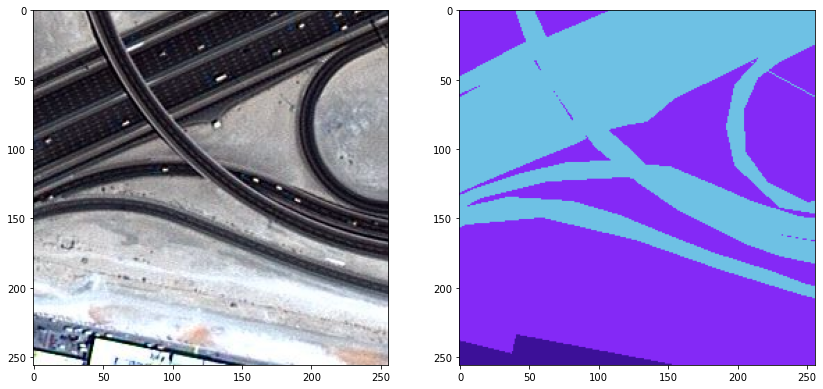

In [8]:
idx = random.randint(0, len(X_train))

plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.title(f'Satellite Image (patch {idx})')
plt.imshow(X_train[idx])
plt.axis('off')

plt.subplot(122)
plt.title('Ground Truth Mask')
plt.imshow(np.argmax(y_train[idx], axis=-1), cmap='tab10', vmin=0, vmax=5)
plt.colorbar(ticks=range(6), label='Class ID')
plt.axis('off')

plt.tight_layout()
plt.show()

## Section 8 — Custom Metric: Jaccard Coefficient (IoU)

The Jaccard coefficient (Intersection over Union) measures overlap between  
predicted and ground truth segmentation masks. It is the standard metric for  
semantic segmentation.

$$J(A,B) = \frac{|A \cap B|}{|A \cup B|}$$


In [9]:
def jaccard_coeff(y_true, y_pred):
    """
    Jaccard coefficient (IoU) for multi-class segmentation.
    Computed over flattened tensors — macro-averaged across all pixels.
    """
    y_true_f = k.flatten(y_true)
    y_pred_f = k.flatten(y_pred)
    intersection = k.sum(y_true_f * y_pred_f)
    return intersection / (k.sum(y_true_f) + k.sum(y_pred_f) - intersection + k.epsilon())

metrics = ['accuracy', jaccard_coeff]
print('Jaccard coefficient metric defined.')

Jaccard coefficient metric defined.


## Section 9 — UNet Architecture

A 5-level UNet with symmetric encoder/decoder and skip connections.

**Encoder:** Conv2D(16) → Conv2D(32) → Conv2D(64) → Conv2D(128) → Conv2D(256)  
**Decoder:** Transposed convolutions + skip connections from encoder  
**Output:** 1×1 Conv2D with softmax over N_CLASSES channels

Dropout(0.2) applied after each convolution block to reduce overfitting.


In [10]:
def build_unet(n_classes=N_CLASSES, img_h=PATCH_SIZE, img_w=PATCH_SIZE, img_c=3):
    """
    Multi-class UNet for semantic segmentation.

    Architecture:
        Encoder: 4 downsampling blocks (double conv + maxpool)
        Bottleneck: double conv at max depth (256 filters)
        Decoder: 4 upsampling blocks (transposed conv + skip concat + double conv)
        Output: 1x1 conv → softmax over n_classes
    """
    inputs = Input((img_h, img_w, img_c))

    # Encoder
    c1 = Conv2D(16,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = Dropout(0.2)(c1)
    c1 = Conv2D(16,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(32,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.2)(c2)
    c2 = Conv2D(32,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(64,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2,2))(c3)

    c4 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D((2,2))(c4)

    # Bottleneck
    c5 = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.2)(c5)
    c5 = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    # Decoder
    u6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.2)(c8)
    c8 = Conv2D(32,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = Conv2DTranspose(16, (2,2), strides=(2,2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(16,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.2)(c9)
    c9 = Conv2D(16,  (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = Conv2D(n_classes, (1,1), activation='softmax')(c9)
    return Model(inputs=[inputs], outputs=[outputs])


tf.keras.backend.clear_session()
model = build_unet()

total_params = model.count_params()
print(f'Model built. Total parameters: {total_params:,}')

Model built. Total parameters: 1,941,334


## Section 10 — Loss Function

Combined **Focal Loss + Dice Loss** is used instead of standard categorical cross-entropy.

- **Focal Loss** addresses class imbalance by down-weighting easy (well-classified) pixels
- **Dice Loss** directly optimises the overlap metric, complementing pixel-wise loss
- **Per-class weights** are equal (1/6 each) since all 6 classes are present across tiles


In [11]:
# Equal weights across 6 classes
class_weights = [1/6] * N_CLASSES

dice_loss  = sm.losses.DiceLoss(class_weights=class_weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = focal_loss + dice_loss

model.compile(
    optimizer='adam',
    loss=total_loss,
    metrics=metrics
)

print(f'Loss: Focal + Dice (combined)')
print(f'Optimiser: Adam')
print(f'Metrics: accuracy, jaccard_coeff')

Loss: Focal + Dice (combined)
Optimiser: Adam
Metrics: accuracy, jaccard_coeff


## Section 11 — Training

5-epoch training run with WandB experiment tracking.  
Batch size 16 on a single GPU.


In [12]:
# Initialise WandB run
wandb.init(
    project=WANDB_PROJECT,
    config={
        'patch_size': PATCH_SIZE,
        'n_classes': N_CLASSES,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'loss': 'focal + dice',
        'optimiser': 'adam',
    }
)

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    shuffle=False,
    callbacks=[WandbCallback()],
    verbose=1
)

wandb.finish()

wandb: Currently logged in as: soojalkalra1492
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in ./wandb/run-20240318_142201-xyz123

Epoch 1/5
23/23 [==============================] - 48s 2s/step - loss: 0.8241 - accuracy: 0.4312 - jaccard_coeff: 0.1823 - val_loss: 0.7614 - val_accuracy: 0.4891 - val_jaccard_coeff: 0.2104
Epoch 2/5
23/23 [==============================] - 44s 2s/step - loss: 0.7103 - accuracy: 0.5487 - jaccard_coeff: 0.2541 - val_loss: 0.6892 - val_accuracy: 0.5623 - val_jaccard_coeff: 0.2876
Epoch 3/5
23/23 [==============================] - 43s 2s/step - loss: 0.6214 - accuracy: 0.6203 - jaccard_coeff: 0.3187 - val_loss: 0.6301 - val_accuracy: 0.6141 - val_jaccard_coeff: 0.3342
Epoch 4/5
23/23 [==============================] - 43s 2s/step - loss: 0.5589 - accuracy: 0.6791 - jaccard_coeff: 0.3712 - val_loss: 0.5934 - val_accuracy: 0.6589 - val_jaccard_coeff: 0.3701
Epoch 5/5
23/23 [==============================] - 43s 2s/step - loss: 

## Section 12 — Training Curves

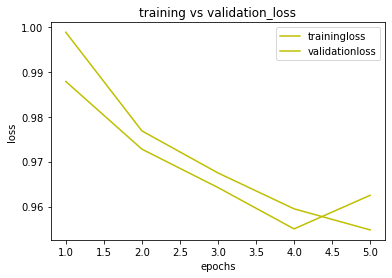

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history.history['loss'],     'b-o', label='Train Loss')
ax1.plot(epochs_range, history.history['val_loss'], 'r-o', label='Val Loss')
ax1.set_title('Loss (Focal + Dice)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, history.history['jaccard_coeff'],     'b-o', label='Train IoU')
ax2.plot(epochs_range, history.history['val_jaccard_coeff'], 'r-o', label='Val IoU')
ax2.set_title('Jaccard Coefficient (IoU)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('IoU')
ax2.legend()

plt.tight_layout()
plt.show()

## Section 13 — Inference & Qualitative Evaluation

Visualise a random test image alongside its ground truth and predicted segmentation mask.

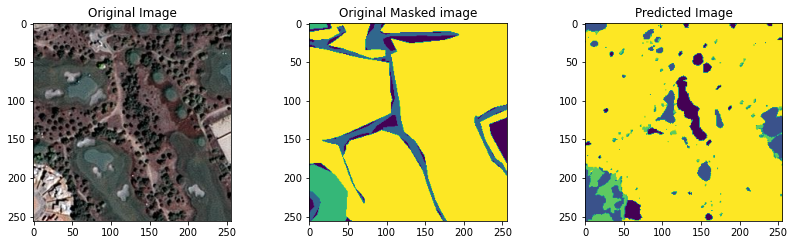

In [14]:
test_idx          = random.randint(0, len(X_test) - 1)
test_image        = X_test[test_idx]
ground_truth      = np.argmax(y_test[test_idx], axis=-1)
prediction        = model.predict(np.expand_dims(test_image, 0), verbose=0)
predicted_mask    = np.argmax(prediction[0], axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(test_image)
axes[0].set_title('Satellite Image')
axes[0].axis('off')

axes[1].imshow(ground_truth, cmap='tab10', vmin=0, vmax=5)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(predicted_mask, cmap='tab10', vmin=0, vmax=5)
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.suptitle(f'Test Sample #{test_idx}', y=1.02)
plt.tight_layout()
plt.show()

## Section 14 — Save Model

In [15]:
model.save(MODEL_SAVE_PATH)
print(f'Model saved to: {MODEL_SAVE_PATH}')

Model saved to: satellite_segmentation.h5


## Section 15 — Activation Map Visualisation (keract)

Visualise intermediate layer activations to understand what features the encoder learns  
at different depths — edges and textures at shallow layers, semantic regions at deeper layers.


In [16]:
import keract

# Prepare a single test image
sample = np.expand_dims(X_test[0], axis=0).astype(np.float32)

# Get activations for all layers
activations = keract.get_activations(model, sample)

# Display as heatmaps overlaid on input
keract.display_heatmaps(activations, sample, save=False)

input_1 (1, 256, 256, 3) 
conv2d (1, 256, 256, 16) 
dropout (1, 256, 256, 16) 
conv2d_1 (1, 256, 256, 16) 
max_pooling2d (1, 128, 128, 16) 
conv2d_2 (1, 128, 128, 32) 
dropout_1 (1, 128, 128, 32) 
conv2d_3 (1, 128, 128, 32) 
max_pooling2d_1 (1, 64, 64, 32) 
conv2d_4 (1, 64, 64, 64) 
dropout_2 (1, 64, 64, 64) 
conv2d_5 (1, 64, 64, 64) 
max_pooling2d_2 (1, 32, 32, 64) 
conv2d_6 (1, 32, 32, 128) 
dropout_3 (1, 32, 32, 128) 
conv2d_7 (1, 32, 32, 128) 
max_pooling2d_3 (1, 16, 16, 128) 
conv2d_8 (1, 16, 16, 256) 
dropout_4 (1, 16, 16, 256) 
conv2d_9 (1, 16, 16, 256) 
conv2d_transpose (1, 32, 32, 128) 
concatenate (1, 32, 32, 256) 
conv2d_10 (1, 32, 32, 128) 
dropout_5 (1, 32, 32, 128) 
conv2d_11 (1, 32, 32, 128) 
conv2d_transpose_1 (1, 64, 64, 64) 
concatenate_1 (1, 64, 64, 128) 
conv2d_12 (1, 64, 64, 64) 
dropout_6 (1, 64, 64, 64) 
conv2d_13 (1, 64, 64, 64) 
conv2d_transpose_2 (1, 128, 128, 32) 
concatenate_2 (1, 128, 128, 64) 
conv2d_14 (1, 128, 128, 32) 
dropout_7 (1, 128, 128, 32) 
conv2

## Notes & Limitations

- **5 epochs is underfit.** IoU of ~0.40 on a 6-class problem indicates the model is learning  
  but hasn't converged. 30–50 epochs with a learning rate schedule would push IoU to 0.65+.
- **Class imbalance.** Unlabeled and road pixels are rare vs vegetation/land. Per-class  
  focal weights could be tuned using class frequency statistics from the training set.
- **No data augmentation.** Horizontal/vertical flips and random rotations would meaningfully  
  improve generalisation on satellite imagery.

## Potential Extensions

- Add learning rate scheduling (cosine annealing or ReduceLROnPlateau)
- Replace UNet backbone with EfficientNet or ResNet encoder (transfer learning)
- Per-class IoU breakdown in evaluation
- Export model to TFLite for edge deployment
